In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
os.getcwd()

'/Users/Angel/Desktop/prism-games/prism-examples/csgs/learning/analysis'

In [34]:
LOGS_DIR = os.getcwd() + "/../logs/"
LOGS_DIR

'/Users/Angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../logs/'

In [35]:
files = sorted(Path(LOGS_DIR).glob("*.csv"))
data = [pd.read_csv(f) for f in files]
names = [f.stem for f in files]

In [36]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,
})

# optional LaTeX (if installed)
plt.rcParams["text.usetex"] = True

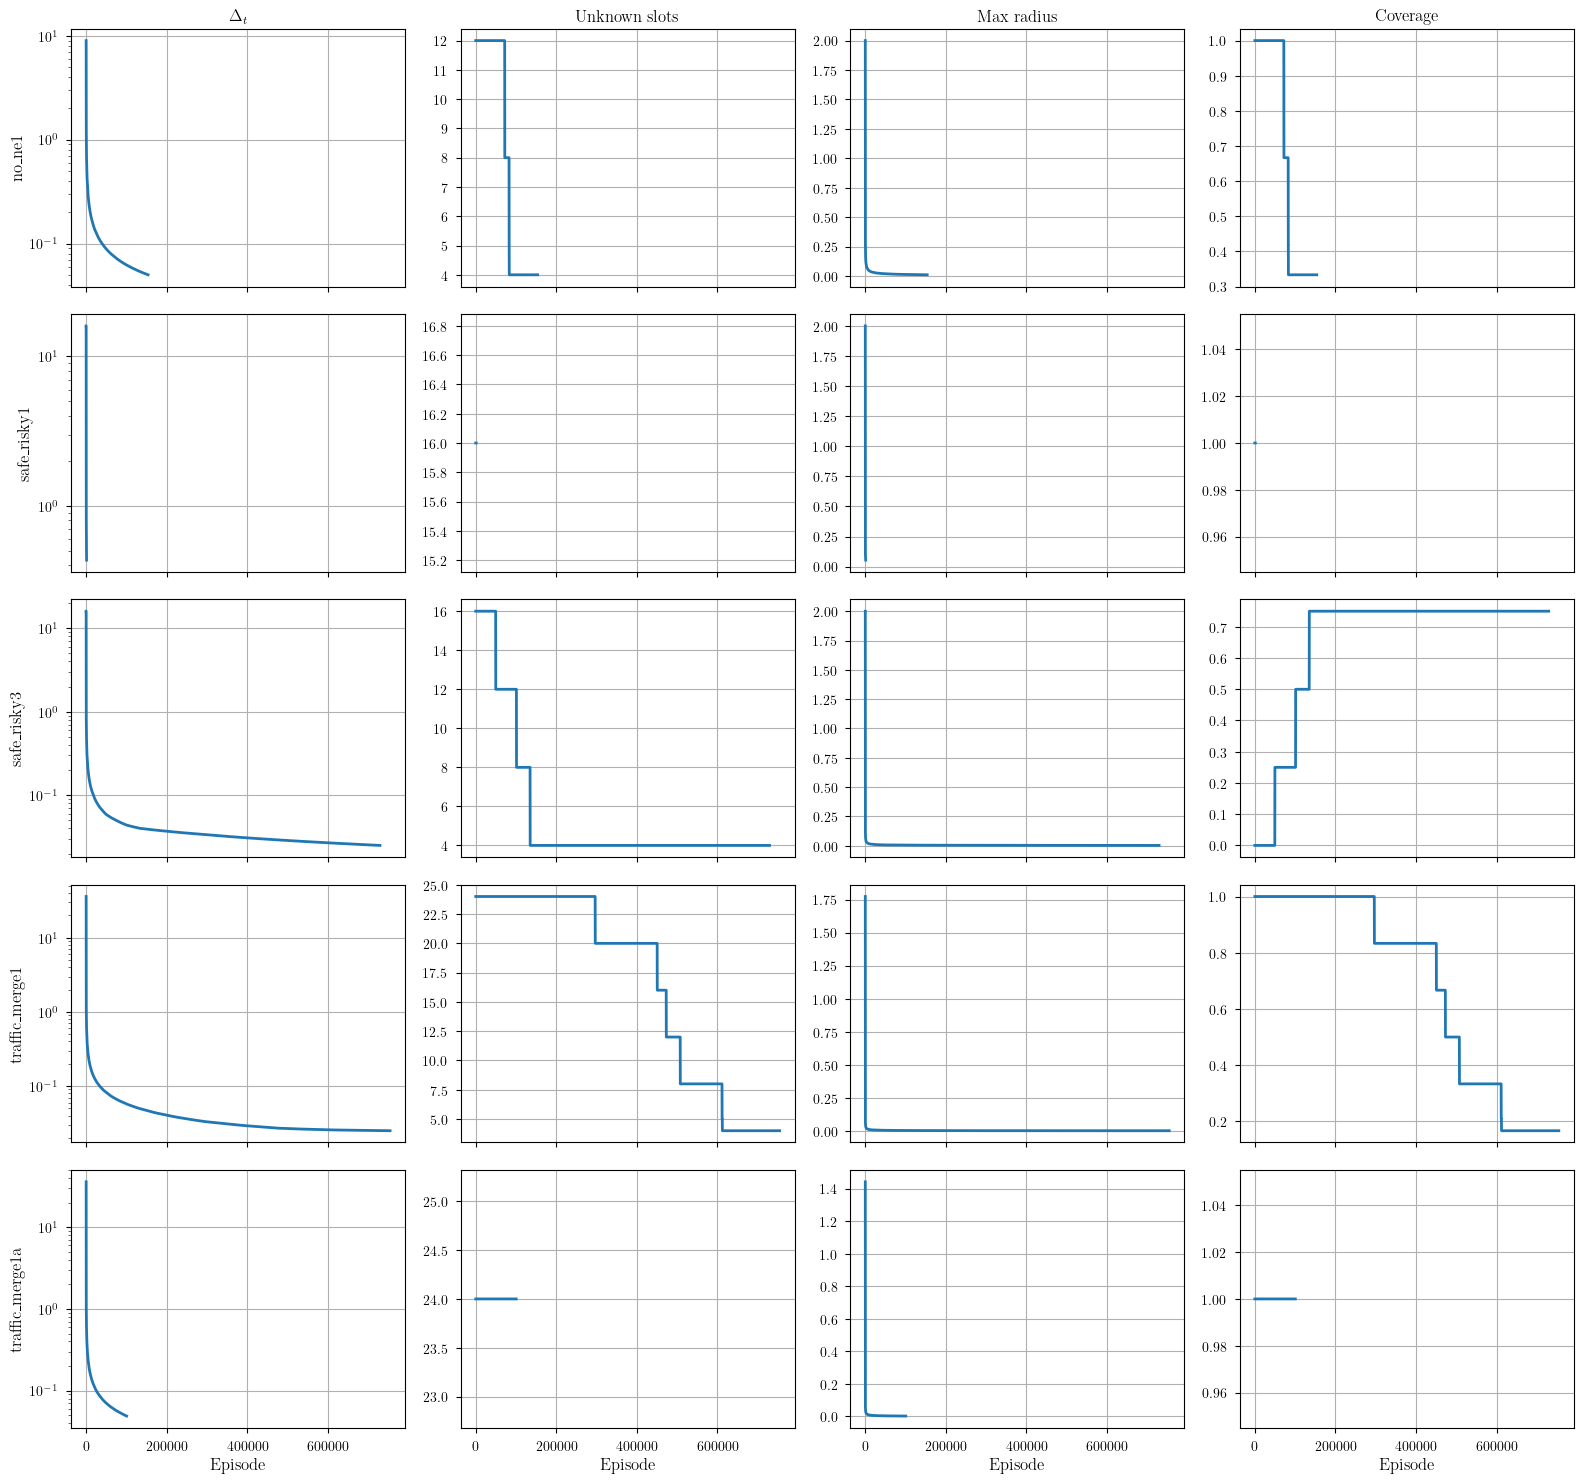

In [37]:
metrics = [
    ("deltaT", r"$\Delta_t$"),
    ("numUnknownSlots", "Unknown slots"),
    ("maxRadius", "Max radius"),
    ("coverage", "Coverage"),
]

num_rows = len(data)
num_cols = len(metrics)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 3*num_rows), sharex=True)

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, df in enumerate(data):
    for j, (col, label) in enumerate(metrics):
        ax = axes[i, j]

        ax.plot(df["episode"], df[col])

        if col == "deltaT":
            ax.set_yscale("log")

        if i == 0:
            ax.set_title(label)

        if j == 0:
            ax.set_ylabel(names[i])

        if i == num_rows - 1:
            ax.set_xlabel("Episode")

        ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
df = pd.read_csv(LOGS_DIR + "safe_risky3.csv")

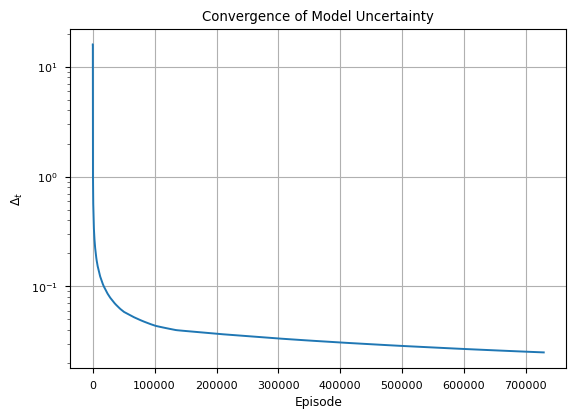

In [19]:
# convergence
plt.figure()
plt.plot(df["episode"], df["deltaT"])
plt.xlabel("Episode")
plt.ylabel(r"$\Delta_t$")
plt.title("Convergence of Model Uncertainty")
plt.yscale("log")  # important for theory alignment
plt.grid(True)
plt.show()

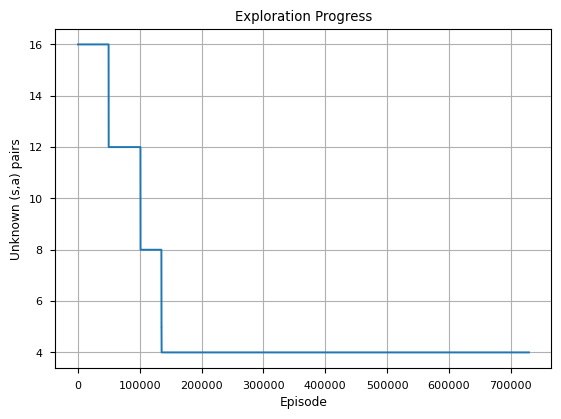

In [21]:
# exploration progress
plt.figure()
plt.plot(df["episode"], df["numUnknownSlots"])
plt.xlabel("Episode")
plt.ylabel("Unknown (s,a) pairs")
plt.title("Exploration Progress")
plt.grid(True)
plt.show()

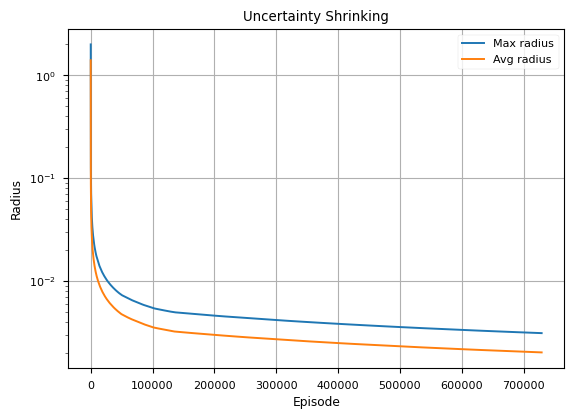

In [23]:
plt.figure()
plt.plot(df["episode"], df["maxRadius"], label="Max radius")
plt.plot(df["episode"], df["avgRadius"], label="Avg radius")
plt.xlabel("Episode")
plt.ylabel("Radius")
plt.yscale("log")
plt.title("Uncertainty Shrinking")
plt.legend()
plt.grid(True)
plt.show()

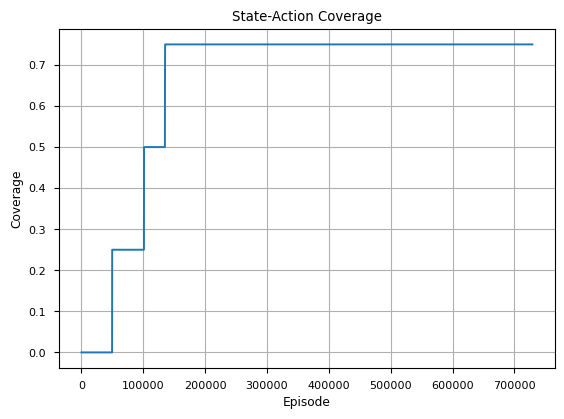

In [24]:
plt.figure()
plt.plot(df["episode"], df["coverage"])
plt.xlabel("Episode")
plt.ylabel("Coverage")
plt.title("State-Action Coverage")
plt.grid(True)
plt.show()

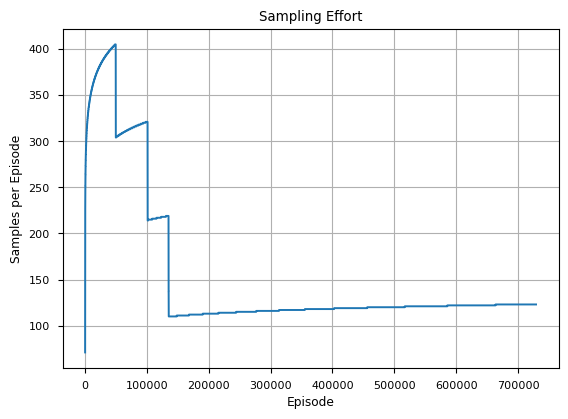

In [25]:
plt.figure()
plt.plot(df["episode"], df["numSamples"])
plt.xlabel("Episode")
plt.ylabel("Samples per Episode")
plt.title("Sampling Effort")
plt.grid(True)
plt.show()